<a href="https://colab.research.google.com/github/dianicgr/An-lisis-Geoespacial/blob/main/entregafinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-2-4214021803.py:16: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  buffer_union = buffer_rios.unary_union
/tmp/ipython-input-2-4214021803.py:30: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/tmp/ipython-input-2-4214021803.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


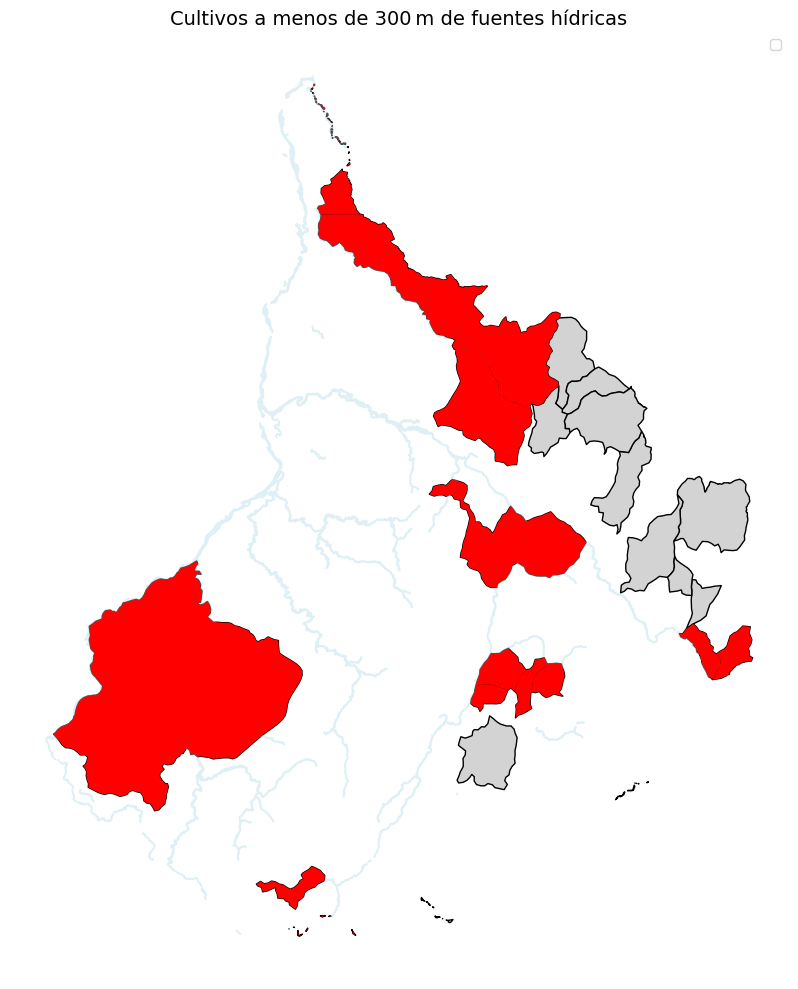

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Cargar los archivos .geojson
cultivos = gpd.read_file("/content/drive/MyDrive/Analisis Geoespacial/entrega_final/Shape/plagui_santander.geojson")     # Polígonos de zonas agrícolas
rios = gpd.read_file("/content/drive/MyDrive/Analisis Geoespacial/entrega_final/Shape/aguasantander.geojson")             # Líneas de ríos/quebradas

# 2. Reproyectar a un sistema en metros (EPSG:3116 - MAGNA SIRGAS Colombia)
cultivos = cultivos.to_crs(epsg=3116)
rios = rios.to_crs(epsg=3116)

# 3. Crear un buffer de 300 metros alrededor de los ríos
buffer_rios = rios.buffer(300)

# 4. Unificar los buffers en una sola geometría para facilitar el análisis
buffer_union = buffer_rios.unary_union

# 5. Filtrar los cultivos que están dentro del buffer (intersección)
cultivos_cerca = cultivos[cultivos.geometry.intersects(buffer_union)]

# 6. Exportar resultados a GeoJSON (opcional)
cultivos_cerca.to_file("cultivos_cerca_rios.geojson", driver="GeoJSON")

# 7. Visualización del resultado
fig, ax = plt.subplots(figsize=(10, 10))
cultivos.plot(ax=ax, color="lightgray", edgecolor="black", label="Todos los cultivos")
gpd.GeoSeries(buffer_union).plot(ax=ax, color="lightblue", alpha=0.4, label="Buffer 300m ríos")
cultivos_cerca.plot(ax=ax, color="red", label="Cultivos cerca de ríos")
ax.set_title("Cultivos a menos de 300 m de fuentes hídricas", fontsize=14)
ax.legend()
ax.set_axis_off()
plt.tight_layout()
plt.show()


/tmp/ipython-input-3-738728492.py:16: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  zona_proteccion = buffer_30m.unary_union
/tmp/ipython-input-3-738728492.py:30: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/tmp/ipython-input-3-738728492.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


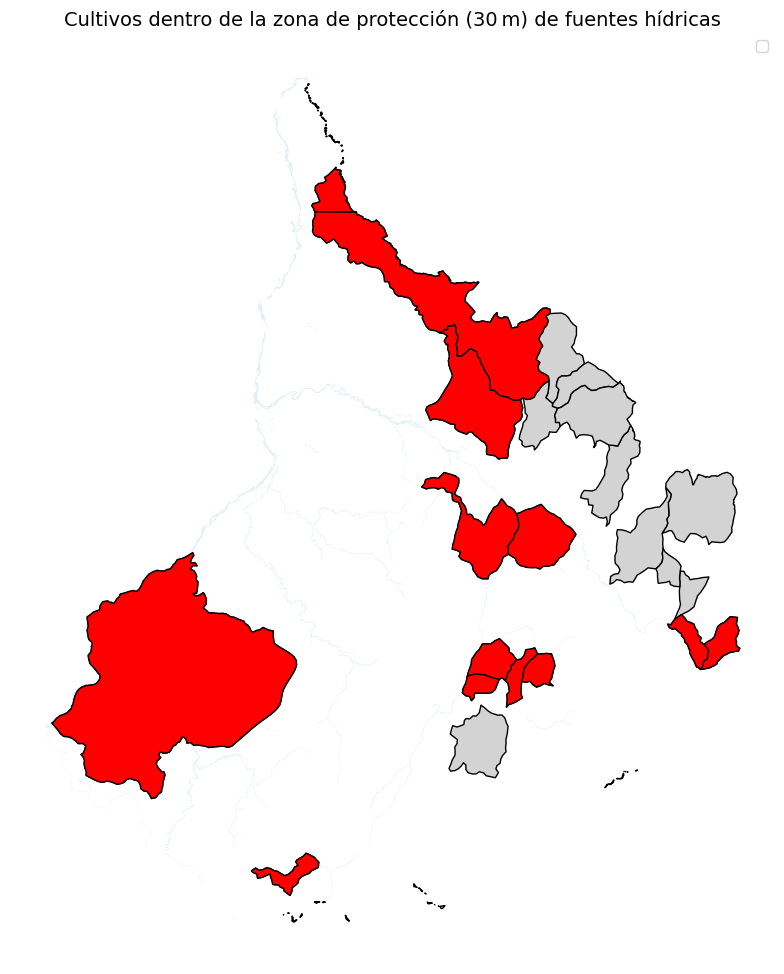

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Cargar archivos .geojson
cultivos = gpd.read_file("/content/drive/MyDrive/Analisis Geoespacial/entrega_final/Shape/plagui_santander.geojson")  # Polígonos
rios = gpd.read_file("/content/drive/MyDrive/Analisis Geoespacial/entrega_final/Shape/aguasantander.geojson")          # Líneas

# 2. Reproyectar a EPSG:3116 (MAGNA-SIRGAS Colombia, en metros)
cultivos = cultivos.to_crs(epsg=3116)
rios = rios.to_crs(epsg=3116)

# 3. Crear buffer de 30 metros alrededor de ríos
buffer_30m = rios.buffer(30)

# 4. Unir los buffers en una sola geometría
zona_proteccion = buffer_30m.unary_union

# 5. Filtrar cultivos que intersectan con la zona de protección
cultivos_en_zona_proteccion = cultivos[cultivos.geometry.intersects(zona_proteccion)]

# 6. Guardar los resultados (opcional)
cultivos_en_zona_proteccion.to_file("cultivos_en_zona_30m.geojson", driver="GeoJSON")

# 7. Visualizar resultados
fig, ax = plt.subplots(figsize=(10, 10))
cultivos.plot(ax=ax, color="lightgray", edgecolor="black", label="Todos los cultivos")
gpd.GeoSeries(zona_proteccion).plot(ax=ax, color="lightblue", alpha=0.4, label="Zona de protección 30 m")
cultivos_en_zona_proteccion.plot(ax=ax, color="red", edgecolor="black", label="Cultivos dentro de los 30 m")
ax.set_title("Cultivos dentro de la zona de protección (30 m) de fuentes hídricas", fontsize=14)
ax.legend()
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [ ]:
import geopandas as gpd

gdf = gpd.read_file("/content/drive/MyDrive/Analisis Geoespacial/entrega_final/Shape/plagui_santander.geojson")
print(gdf.columns)


Index(['fid', 'OBJECTID', 'Cod_dane', 'Valor_AF', 'Valor_Bprd', 'Valor_Crbm',
       'Valor_Orgn', 'Valor_Orgf', 'Valor_Otro', 'Valor_Ot_1', 'usoplaguic',
       'SHAPE_Leng', 'SHAPE_Area', 'RULEID', 'Longitud', 'Latitud', 'tipo',
       'a_aguas', 'a_cultivos', 'a_otros', 'a_pastos', 'a_total', 'geometry'],
      dtype='object')


In [ ]:
import geopandas as gpd
import fiona
from shapely.geometry import shape, MultiPolygon, MultiLineString
import json

# 📌 Ruta al archivo
ruta = "/content/drive/MyDrive/Analisis Geoespacial/entrega_final/Shape/plagui_santander.geojson"

# Leer el archivo como JSON para extraer geometrías correctamente
with open(ruta, "r", encoding="utf-8") as f:
    geojson = json.load(f)

features = geojson["features"]

geometries_limpias = []
props_limpios = []

# Descomponer MultiPolygons o MultiLineStrings en partes individuales
for feat in features:
    props = feat["properties"]
    geom = shape(feat["geometry"])

    if isinstance(geom, (MultiPolygon, MultiLineString)):
        for subgeom in geom.geoms:
            geometries_limpias.append(subgeom)
            props_limpios.append(dict(props))  # Convertir a dict normal
    else:
        geometries_limpias.append(geom)
        props_limpios.append(dict(props))

# Crear el GeoDataFrame limpio
gdf_limpio = gpd.GeoDataFrame(props_limpios, geometry=geometries_limpias)
gdf_limpio.set_crs("EPSG:4326", inplace=True)  # o ajusta según el sistema de referencia original

# Verifica
gdf_limpio.head()


,fid,OBJECTID,Cod_dane,Valor_AF,Valor_Bprd,Valor_Crbm,Valor_Orgn,Valor_Orgf,Valor_Otro,Valor_Ot_1,...,RULEID,Longitud,Latitud,tipo,a_aguas,a_cultivos,a_otros,a_pastos,a_total,geometry
0,1,17,15632,0.0,0.0,7.0,0.0,36.0,0.0,2.0,...,1,-73.75618,5.735993,otros,0.0,0.0,0.159,0.952,1.11,"POLYGON ((4927141.35771 2189841.12432, 4927082..."
1,1,17,15632,0.0,0.0,7.0,0.0,36.0,0.0,2.0,...,1,-73.75618,5.735993,otros,0.0,0.0,0.159,0.952,1.11,"POLYGON ((4919702.15475 2195748.53888, 4919698..."
2,1,17,15632,0.0,0.0,7.0,0.0,36.0,0.0,2.0,...,1,-73.75618,5.735993,otros,0.0,0.0,0.159,0.952,1.11,"POLYGON ((4917977.28833 2195826.94873, 4917973..."
3,1,17,15632,0.0,0.0,7.0,0.0,36.0,0.0,2.0,...,1,-73.75618,5.735993,otros,0.0,0.0,0.159,0.952,1.11,"POLYGON ((4912384.87517 2191947.04382, 4912388..."
4,1,17,15632,0.0,0.0,7.0,0.0,36.0,0.0,2.0,...,1,-73.75618,5.735993,otros,0.0,0.0,0.159,0.952,1.11,"POLYGON ((4910691.10491 2190087.07737, 4910687..."


In [ ]:
# 1. Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Importar librerías
import geopandas as gpd
import os

# 3. Definir rutas
folder = "/content/drive/MyDrive/Analisis_Geoespacial/entrega_final/Shape"
os.makedirs(folder, exist_ok=True)

# 4. Rutas a los archivos GeoJSON
ruta_agricolas = os.path.join(folder, "/content/drive/MyDrive/Analisis Geoespacial/entrega_final/Shape/plagui_santander.geojson")
ruta_hidricas = os.path.join(folder, "/content/drive/MyDrive/Analisis Geoespacial/entrega_final/Shape/aguasantander.geojson")

# 5. Leer archivos GeoJSON
agricolas = gpd.read_file(ruta_agricolas)
hidricas = gpd.read_file(ruta_hidricas)

# 6. Verificar y unificar sistema de referencia (CRS)
if agricolas.crs != hidricas.crs:
    hidricas = hidricas.to_crs(agricolas.crs)

# ⚠️ OPCIONAL: Reproyectar a un sistema métrico si están en grados (EPSG:4326)
# Esto es importante si quieres hacer buffers o medir áreas en metros
if agricolas.crs.to_epsg() == 4326:
    agricolas = agricolas.to_crs("EPSG:9377")  # Proyección para Colombia
    hidricas = hidricas.to_crs("EPSG:9377")

# 7. Crear buffer de 100 metros alrededor de las fuentes hídricas
hidricas_buffer = hidricas.copy()
hidricas_buffer["geometry"] = hidricas_buffer.buffer(100)

# 8. Intersección espacial
interseccion = gpd.overlay(agricolas, hidricas_buffer, how="intersection")

# 9. Calcular área en metros cuadrados
interseccion["area_m2"] = interseccion.geometry.area

# 10. Guardar como GeoJSON
salida = os.path.join(folder, "interseccion_agricola_hidrica.geojson")
interseccion.to_file(salida, driver="GeoJSON")

# 11. Mostrar resumen del área
interseccion[["area_m2"]].describe()



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,area_m2
count,1.500000e+01
mean,1.193905e+07
std,3.241625e+07
min,1.089314e+04
25%,4.374124e+05
50%,1.520532e+06
75%,6.311268e+06
max,1.275239e+08


In [ ]:
# 1. Instalar paquetes necesarios
!pip install geopandas pykrige matplotlib

# 2. Importar librerías
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from pykrige.ok import OrdinaryKriging

# 3. Cargar archivo GeoJSON desde Google Drive
ruta = "/content/drive/MyDrive/Analisis Geoespacial/entrega_final/Shape/plagui_santander.geojson"
gdf_plag = gpd.read_file(ruta)

# 4. Asegurar sistema de coordenadas WGS84
gdf_plag = gdf_plag.to_crs(epsg=4326)

# 5. Extraer centroides de las geometrías (si no son puntos)
gdf_plag["centroid"] = gdf_plag.geometry.centroid
gdf_plag.set_geometry("centroid", inplace=True)

# 6. Obtener coordenadas X, Y desde los centroides
gdf_plag["x"] = gdf_plag.geometry.x
gdf_plag["y"] = gdf_plag.geometry.y

# 7. Seleccionar solo puntos con valores válidos de 'totalpla'
gdf_validos = gdf_plag[gdf_plag["totalpla"].notnull()]

# 8. Extraer arrays de coordenadas y valores
x = gdf_validos["x"].values
y = gdf_validos["y"].values
z = gdf_validos["totalpla"].values

# 9. Crear la malla para interpolar
gridx = np.linspace(x.min(), x.max(), 100)
gridy = np.linspace(y.min(), y.max(), 100)

# 10. Aplicar Kriging ordinario (variograma tipo "gaussian")
OK = OrdinaryKriging(
    x, y, z,
    variogram_model='gaussian',
    verbose=False,
    enable_plotting=False
)

# 11. Interpolación
z_pred, ss = OK.execute("grid", gridx, gridy)

# 12. Visualizar resultado
plt.figure(figsize=(10, 8))
plt.contourf(gridx, gridy, z_pred, cmap='viridis')
plt.colorbar(label='Interpolación de totalpla')
plt.scatter(x, y, c='red', s=10, label='Datos')
plt.title("Kriging Ordinario - Concentración Total de Plaguicidas")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend()
plt.show()


/tmp/ipython-input-49-1073953291.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_plag["centroid"] = gdf_plag.geometry.centroid


KeyError: 'totalpla'

In [ ]:
print(gdf.columns)